In [1]:
import os
import numpy as np
import pandas as pd

from sklearn.linear_model import Ridge, ElasticNet
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import xgboost as xgb
import lightgbm as lgb

In [2]:
DATA_DIR = "/data1/yashvi_bhuva/BP_estimation_using_PPG/UCI/Feature_extraction/Non_fiducial_features/8sec_50%overlap/data"

train_path = os.path.join(DATA_DIR, "DBP_FTEST_train.csv")
val_path   = os.path.join(DATA_DIR, "DBP_FTEST_val.csv")
test_path  = os.path.join(DATA_DIR, "DBP_FTEST_test.csv")

df_train = pd.read_csv(train_path)
df_val   = pd.read_csv(val_path)
df_test  = pd.read_csv(test_path)

print("Train:", df_train.shape)
print("Val:  ", df_val.shape)
print("Test: ", df_test.shape)

Train: (522837, 16)
Val:   (66013, 16)
Test:  (66296, 16)


In [3]:
print(df_train.head()) 
print(df_train.columns.tolist())

   apg_kte_iqr  apg_kte_mean   apg_iqr  ppg_mean  vpg_median   apg_std  \
0    -0.572492     -0.532378 -0.413659  3.275178   -2.876354 -0.804523   
1    -0.388884     -0.502156 -0.225501  3.164993   -3.003903 -0.684995   
2    -0.517974     -0.558633 -0.249330  2.857067   -3.111302 -0.767649   
3    -0.642227     -0.328611 -0.461616  3.002455   -2.979920 -0.651191   
4    -0.646398     -0.679543 -0.543978  3.197217   -2.926226 -1.014502   

   vpg_kte_mean  ppg_median  apg_variance  apg_energy_mean  apg_median  \
0     -0.721283    3.324933     -0.751883        -0.751619   -1.597076   
1     -0.653803    3.146717     -0.671373        -0.671381   -1.512170   
2     -0.693261    2.851387     -0.727458        -0.727233   -1.197077   
3     -0.537563    2.956267     -0.647902        -0.647717   -1.205045   
4     -0.857860    3.175345     -0.883951        -0.883900   -1.532645   

   ppg_shannon_entropy  ppg_skewness  ppg_energy_skewness   ppg_std        DBP  
0             1.582286     -2

In [4]:
TARGET = "DBP"

X_train = df_train.drop(columns=[TARGET])
y_train = df_train[TARGET]

X_val = df_val.drop(columns=[TARGET])
y_val = df_val[TARGET]

X_test = df_test.drop(columns=[TARGET])
y_test = df_test[TARGET]

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_val:  ", X_val.shape)
print("y_val:  ", y_val.shape)
print("X_test: ", X_test.shape)
print("y_test: ", y_test.shape)

X_train: (522837, 15)
y_train: (522837,)
X_val:   (66013, 15)
y_val:   (66013,)
X_test:  (66296, 15)
y_test:  (66296,)


In [5]:
X_dev = pd.concat([X_train, X_val], axis=0)
y_dev = pd.concat([y_train, y_val], axis=0)

In [6]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def print_metrics(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    print(f"RMSE: {rmse:.4f}")
    print(f"MSE : {mse:.4f}")
    print(f"MAE : {mae:.4f}")
    print(f"R²  : {r2:.4f}")

from matplotlib import pyplot as plt

import numpy as np
import matplotlib.pyplot as plt

def plot_regression_results(
    y_true,
    y_pred,
    model_name,
    target_name=TARGET
):

    residuals = y_true - y_pred

    # ----------------------------------------
    # 1. TRUE VS PREDICTED
    # ----------------------------------------
    plt.figure(figsize=(7, 6))

    plt.scatter(y_true, y_pred, alpha=0.3)

    min_val = min(y_true.min(), y_pred.min())
    max_val = max(y_true.max(), y_pred.max())

    plt.plot(
        [min_val, max_val],
        [min_val, max_val],
        linestyle="--",
        label="Ideal (y = x)"
    )

    plt.xlabel(f"True {target_name} (mmHg)")
    plt.ylabel(f"Predicted {target_name} (mmHg)")
    plt.title(f"{model_name} — {target_name}: True vs Predicted")

    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


    # ----------------------------------------
    # 2. RESIDUAL VS PREDICTED
    # ----------------------------------------
    plt.figure(figsize=(7, 5))

    plt.scatter(y_pred, residuals, alpha=0.3)

    plt.axhline(0, linestyle="--")

    plt.xlabel(f"Predicted {target_name} (mmHg)")
    plt.ylabel("Residual (mmHg)")
    plt.title(f"{model_name} — {target_name}: Residual Plot")

    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


    # ----------------------------------------
    # 3. RESIDUAL DISTRIBUTION
    # ----------------------------------------
    plt.figure(figsize=(7, 5))

    plt.hist(residuals, bins=50, alpha=0.7)

    plt.axvline(0, linestyle="--")

    plt.xlabel("Residual (mmHg)")
    plt.ylabel("Frequency")
    plt.title(f"{model_name} — {target_name}: Residual Distribution")

    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


    # ----------------------------------------
    # 4. MAE VS TRUE TARGET RANGE
    # ----------------------------------------

    # Different ranges depending on target
    if target_name.upper() == "DBP":
        bins = [50, 60, 70, 80, 90, 100, 120, 150]
    else:
        # SBP
        bins = [70, 80, 100, 120, 140, 160, 180, 200]

    mae_values = []
    sample_counts = []
    range_labels = []

    for i in range(len(bins) - 1):

        lower = bins[i]
        upper = bins[i + 1]

        mask = (
            (y_true >= lower) &
            (y_true < upper)
        )

        count = np.sum(mask)

        # Skip range if there are no samples
        if count == 0:
            continue

        mae = np.mean(
            np.abs(
                y_true[mask] - y_pred[mask]
            )
        )

        mae_values.append(mae)
        sample_counts.append(count)
        range_labels.append(
            f"{lower}–{upper}"
        )

    # Plot
    plt.figure(figsize=(9, 5))

    bars = plt.bar(
        range_labels,
        mae_values
    )

    plt.xlabel(
        f"True {target_name} range (mmHg)"
    )

    plt.ylabel("MAE (mmHg)")

    plt.title(
        f"{model_name} — {target_name}: "
        f"MAE by True Target Range"
    )

    # Add MAE and number of samples
    for bar, mae, count in zip(
        bars,
        mae_values,
        sample_counts
    ):

        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            f"{mae:.2f}\n(n={count:,})",
            ha="center",
            va="bottom",
            fontsize=9
        )

    plt.grid(
        axis="y",
        alpha=0.3
    )

    plt.tight_layout()
    plt.show()

## SIMPLE LINEAR REGRESSION ##

In [7]:
from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()

linear_model.fit(X_dev, y_dev)

y_test_pred = linear_model.predict(X_test)

print("Simple Linear Regression")
print("------------------------")
print_metrics(y_test, y_test_pred)

Simple Linear Regression
------------------------
RMSE: 10.7367
MSE : 115.2770
MAE : 8.2856
R²  : 0.1278


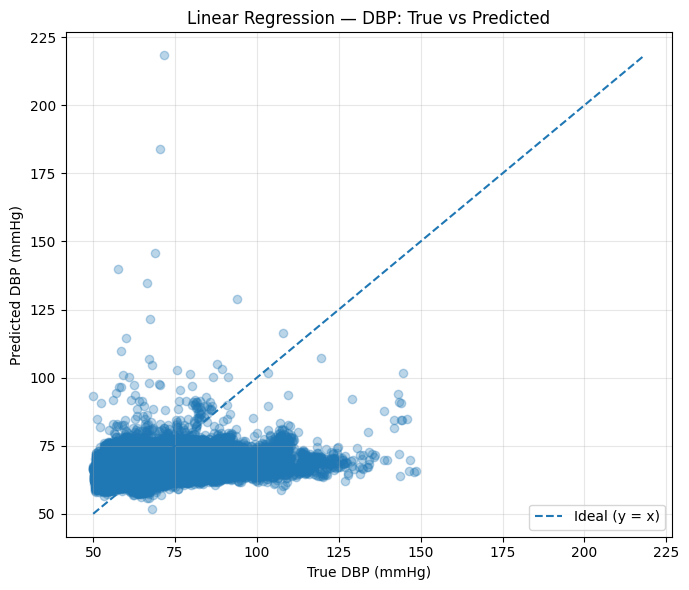

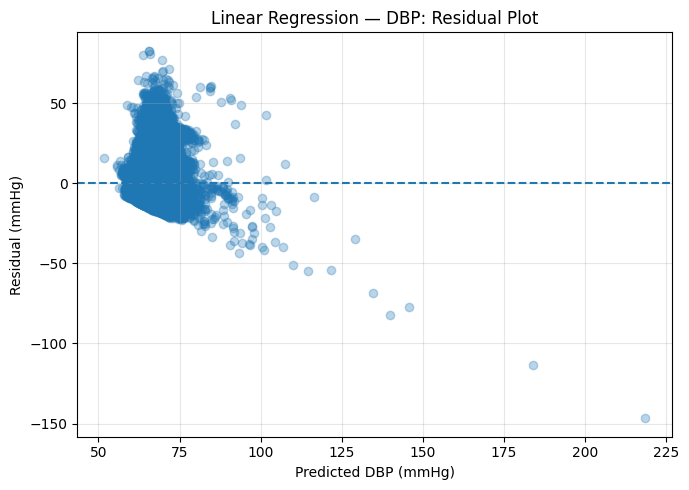

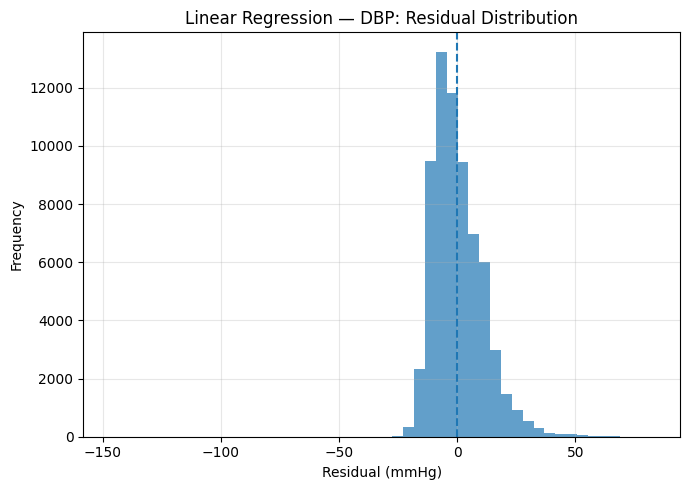

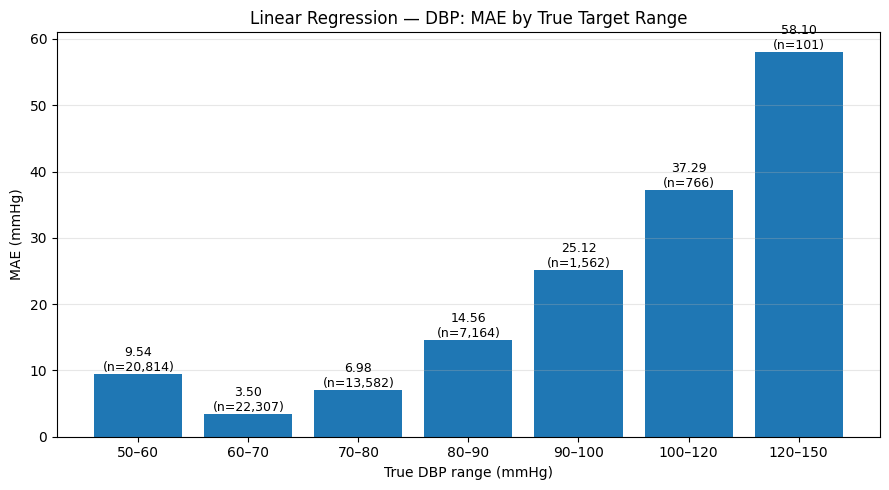

In [8]:
plot_regression_results(
    y_test,
    y_test_pred,
    "Linear Regression"
)

## INTERACTION LINEAR REGRESSION ##

In [8]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

interaction_model = Pipeline([
    ("poly", PolynomialFeatures(
        degree=2,
        interaction_only=True,
        include_bias=False
    )),
    ("linear", LinearRegression())
])

param_grid = {
    "linear__fit_intercept": [True, False]
}

grid_interaction = GridSearchCV(
    interaction_model,
    param_grid=param_grid,
    scoring="neg_mean_squared_error",
    cv=3,
    n_jobs=2
)

grid_interaction.fit(X_dev, y_dev)

print("Best parameters:")
print(grid_interaction.best_params_)

y_test_pred = grid_interaction.predict(X_test)

print("\nInteraction Linear Regression")
print("-----------------------------")
print_metrics(y_test, y_test_pred)

Best parameters:
{'linear__fit_intercept': True}

Interaction Linear Regression
-----------------------------
RMSE: 36.6547
MSE : 1343.5686
MAE : 8.2395
R²  : -9.1662


## Robust Linear Regression ##

In [9]:
from sklearn.linear_model import HuberRegressor

robust_model = HuberRegressor(
    max_iter=1000
)

param_grid = {
    "epsilon": [1.1, 1.35, 1.5, 2.0],
    "alpha": [0.0001, 0.001, 0.01, 0.1, 1.0]
}

grid_robust = GridSearchCV(
    robust_model,
    param_grid=param_grid,
    scoring="neg_mean_squared_error",
    cv=3,
    n_jobs=2
)

grid_robust.fit(X_dev, y_dev)

print("Best parameters:")
print(grid_robust.best_params_)

y_test_pred = grid_robust.predict(X_test)

print("\nRobust Linear Regression")
print("------------------------")
print_metrics(y_test, y_test_pred)

Best parameters:
{'alpha': 1.0, 'epsilon': 2.0}

Robust Linear Regression
------------------------
RMSE: 10.9426
MSE : 119.7401
MAE : 8.3658
R²  : 0.0940


## Fine Decision Tree ##

In [ ]:
from sklearn.tree import DecisionTreeRegressor

fine_tree = DecisionTreeRegressor(
    random_state=42
)

param_grid = {
    "max_depth": [10, 15, 20, 25, 30, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

grid_fine_tree = GridSearchCV(
    fine_tree,
    param_grid=param_grid,
    scoring="neg_mean_squared_error",
    cv=3,
    n_jobs=2
)

grid_fine_tree.fit(X_dev, y_dev)

print("Best parameters:")
print(grid_fine_tree.best_params_)

y_test_pred = grid_fine_tree.predict(X_test)

print("\nFine Decision Tree")
print("------------------")
print_metrics(y_test, y_test_pred)

## Random Forest ##

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    random_state=42,
    n_jobs=2
)

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2],
    "max_features": ["sqrt"]
}

grid_rf = GridSearchCV(
    rf,
    param_grid=param_grid,
    scoring="neg_mean_squared_error",
    cv=3,
    n_jobs=2
)

grid_rf.fit(X_dev, y_dev)

print("Best parameters:")
print(grid_rf.best_params_)

y_test_pred = grid_rf.predict(X_test)

print("\nRandom Forest")
print("-------------")
print_metrics(y_test, y_test_pred)

## Extra TREES ##

In [ ]:
from sklearn.ensemble import ExtraTreesRegressor

extra_trees = ExtraTreesRegressor(
    random_state=42,
    n_jobs=2
)

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 20, 30],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2],
    "max_features": [1.0, "sqrt"]
}

grid_extra_trees = GridSearchCV(
    estimator=extra_trees,
    param_grid=param_grid,
    scoring="neg_mean_squared_error",
    cv=3,
    n_jobs=2
)

grid_extra_trees.fit(X_dev, y_dev)

print("Best parameters:")
print(grid_extra_trees.best_params_)

y_test_pred = grid_extra_trees.predict(X_test)

print("Extra Trees Regressor")
print("---------------------")
print_metrics(y_test, y_test_pred)

## XGBOOST ##

In [ ]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    objective="reg:squarederror",
    random_state=42,
    n_jobs=2
)

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [3, 6],
    "learning_rate": [0.05, 0.1],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

grid_xgb = GridSearchCV(
    xgb,
    param_grid=param_grid,
    scoring="neg_mean_squared_error",
    cv=3,
    n_jobs=2
)

grid_xgb.fit(X_dev, y_dev)

print("Best parameters:")
print(grid_xgb.best_params_)

y_test_pred = grid_xgb.predict(X_test)

print("\nXGBoost")
print("-------")
print_metrics(y_test, y_test_pred)

## Light GBM ##

In [ ]:
from lightgbm import LGBMRegressor
from sklearn.model_selection import GridSearchCV

lgbm = LGBMRegressor(
    objective="regression",
    random_state=42,
    n_jobs=2,
    verbosity=-1
)

param_grid = {
    "n_estimators": [100, 200],
    "learning_rate": [0.05, 0.1],
    "num_leaves": [15, 31],
    "max_depth": [-1, 10]
}

grid_lgbm = GridSearchCV(
    estimator=lgbm,
    param_grid=param_grid,
    scoring="neg_mean_squared_error",
    cv=3,
    n_jobs=2,
    verbose=2
)

grid_lgbm.fit(X_dev, y_dev)

print("Best parameters:")
print(grid_lgbm.best_params_)

y_test_pred = grid_lgbm.predict(X_test)

print("\nLightGBM")
print("--------")
print_metrics(y_test, y_test_pred)

##  Matern 5/2 gpr ##

In [ ]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import (
    Matern,
    ConstantKernel,
    WhiteKernel
)
from sklearn.model_selection import GridSearchCV
import numpy as np

# --------------------------------------------------
# Take a manageable subset for GPR
# --------------------------------------------------

N_GPR = 5000

rng = np.random.RandomState(42)

indices = rng.choice(
    len(X_dev),
    size=N_GPR,
    replace=False
)

X_gpr = X_dev.iloc[indices]
y_gpr = y_dev.iloc[indices]


# --------------------------------------------------
# Matern 5/2 GPR
# --------------------------------------------------

gpr_matern = GaussianProcessRegressor(
    normalize_y=True,
    random_state=42,
    n_restarts_optimizer=1
)


# --------------------------------------------------
# Grid of Matern 5/2 kernels
# --------------------------------------------------

param_grid = {
    "kernel": [
        ConstantKernel(1.0)
        * Matern(
            length_scale=0.5,
            nu=2.5
        )
        + WhiteKernel(
            noise_level=1.0
        ),

        ConstantKernel(1.0)
        * Matern(
            length_scale=1.0,
            nu=2.5
        )
        + WhiteKernel(
            noise_level=1.0
        ),

        ConstantKernel(1.0)
        * Matern(
            length_scale=2.0,
            nu=2.5
        )
        + WhiteKernel(
            noise_level=1.0
        )
    ]
}


# --------------------------------------------------
# GridSearchCV
# --------------------------------------------------

grid_gpr_matern = GridSearchCV(
    estimator=gpr_matern,
    param_grid=param_grid,
    scoring="neg_mean_squared_error",
    cv=3,
    n_jobs=1
)


# --------------------------------------------------
# Fit
# --------------------------------------------------

grid_gpr_matern.fit(
    X_gpr,
    y_gpr
)


# --------------------------------------------------
# Best parameters
# --------------------------------------------------

print("Best parameters:")
print(grid_gpr_matern.best_params_)


# --------------------------------------------------
# Test prediction
# --------------------------------------------------

y_test_pred = grid_gpr_matern.predict(X_test)


# --------------------------------------------------
# Metrics
# --------------------------------------------------

print("\nMatern 5/2 GPR")
print("--------------")

print_metrics(y_test, y_test_pred)

## Rational Quadratic GPR ##

In [ ]:
from sklearn.gaussian_process.kernels import (
    ConstantKernel,
    RationalQuadratic,
    WhiteKernel
)
gpr = GaussianProcessRegressor(
    normalize_y=True,
    random_state=42
)

param_grid = {
    "kernel": [
        ConstantKernel(1.0) *
        RationalQuadratic(
            length_scale=1.0,
            alpha=1.0
        ) +
        WhiteKernel(noise_level=1.0),

        ConstantKernel(1.0) *
        RationalQuadratic(
            length_scale=0.5,
            alpha=1.0
        ) +
        WhiteKernel(noise_level=1.0),

        ConstantKernel(1.0) *
        RationalQuadratic(
            length_scale=2.0,
            alpha=1.0
        ) +
        WhiteKernel(noise_level=1.0)
    ]
}

grid_gpr_rq = GridSearchCV(
    estimator=gpr,
    param_grid=param_grid,
    scoring="neg_mean_squared_error",
    cv=3,
    n_jobs=1
)

grid_gpr_rq.fit(
    X_gpr,
    y_gpr
)

print("Best parameters:")
print(grid_gpr_rq.best_params_)


y_test_pred = grid_gpr_rq.predict(X_test)


print("Rational Quadratic GPR")
print("----------------------")
print_metrics(y_test, y_test_pred)

## ANN ##

In [ ]:
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import GridSearchCV

ann = MLPRegressor(
    random_state=42,
    max_iter=300,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=20
)

param_grid = {
    "hidden_layer_sizes": [
        (64, 32),
        (128, 64),
        (64, 32, 16)
    ],
    "activation": ["relu"],
    "alpha": [0.0001, 0.001, 0.01],
    "learning_rate_init": [0.001, 0.01],
    "batch_size": [256, 512]
}

grid_ann = GridSearchCV(
    estimator=ann,
    param_grid=param_grid,
    scoring="neg_mean_squared_error",
    cv=3,
    n_jobs=2,
    verbose=1
)

grid_ann.fit(X_gpr, y_gpr)

print("Best parameters:")
print(grid_ann.best_params_)

y_test_pred = grid_ann.predict(X_test)

print("ANN / MLP Regressor")
print("-------------------")
print_metrics(y_test, y_test_pred)